In [53]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [82]:
stats_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/B_varreduction/AVERAGE_Station_pca_variables.csv")
weathercluster_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/weather_7.csv")
GEV_clusters = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/station_GEV_7.csv")
Static_contr = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/static_contributers.csv")

GEV_clusters = GEV_clusters[~GEV_clusters["cluster"].isin([0, 5])].copy()

stats_df["station"] = stats_df["station"].astype(int)
GEV_clusters["station"] = GEV_clusters["station"].astype(int)
GEV_clusters["cluster_id"] = GEV_clusters["cluster"]

label_df = GEV_clusters[["station", "cluster", "cluster_id", "lat", "lon"]].dropna().copy()
label_df["cluster"] = label_df["cluster"].astype(int)

# Inner join: only stations that exist in both
model_df = stats_df.merge(label_df, on=["station",], how="inner")
model_df = model_df.merge(Static_contr, on=["station","lat", "lon", "cluster"], how="inner")

unique_clusters = sorted(model_df["cluster"].unique())
# Build mapping → start numbering from 1
cluster_map = {old: new for new, old in enumerate(unique_clusters, start=1)}
# Apply remapping
model_df["cluster"] = model_df["cluster"].map(cluster_map)

In [83]:

print("Stations for modeling:", len(model_df))
print(model_df["cluster"].value_counts(dropna=False))

drop_cols = {"station", "cluster"}
forbidden_substrings = ("sea_level","residual","tide","lat","lon","count","missing_frac",
                        "extract_time","name","unnamed", "name", "Unnamed", 'HYRIV' , "gev", "ks", "kuiper", "r2", "dist_to_CVI_m",
                        "dist_to_morpho_m", "H", "id", "ID", "HYR", "GEOM", "POINT", "index", "geometry")

# Drop any column containing forbidden substrings (case-insensitive)
forbidden_cols = {
    c for c in model_df.columns
    if any(sub in c.lower() for sub in forbidden_substrings)
}
cols_to_drop = drop_cols | forbidden_cols
#model_df = model_df.groupby("station").mean(numeric_only=True)
model_df = model_df.reset_index().groupby("station").agg(
    lambda x: x.max() if pd.api.types.is_numeric_dtype(x)
    else x.mode().iloc[0]
)
# Compute cluster sizes
cluster_counts = model_df["cluster_id"].value_counts()

# Keep only stations belonging to clusters with >1 entry
model_df = model_df[model_df["cluster_id"].isin(cluster_counts[cluster_counts > 1].index)]

# Build feature matrix
X = model_df.drop(columns=[c for c in cols_to_drop if c in model_df.columns])

y = model_df['cluster_id']
X = X.replace([np.inf, -np.inf], np.nan)

Stations for modeling: 344
cluster
3    115
1    109
4     82
2     22
5     16
Name: count, dtype: int64


In [84]:
cat_cols = X.select_dtypes(include=["object", "category"]).columns
num_cols = X.select_dtypes(include=["number"]).columns

# Impute numeric
X[num_cols] = X[num_cols].apply(lambda s: s.fillna(s.median()))

# Impute categoricals
X[cat_cols] = X[cat_cols].astype(str).fillna("__missing__")

# Standardize categorical strings
X[cat_cols] = X[cat_cols].apply(lambda s: s.str.strip().str.lower())

In [86]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X[num_cols])

from sklearn.decomposition import PCA

pca = PCA(n_components=0.90, random_state=0)
X_num_pca = pca.fit_transform(X_num_scaled)

print("Original numeric features:", len(num_cols))
print("PCA components kept:", X_num_pca.shape[1])

import pandas as pd

explained = pd.Series(
    pca.explained_variance_ratio_,
    name="variance_explained"
)

print(explained)
print("\nTotal variance retained:", explained.sum())

cumvar = explained.cumsum()
print("\nCumulative variance:")
print(cumvar)

loadings = pd.DataFrame(
    pca.components_.T,
    index=num_cols,
    columns=[f"PC{i+1}" for i in range(X_num_pca.shape[1])]
)

# Show top drivers per component
for pc in loadings.columns:
    print(f"\nTop contributors to {pc}:")
    print(loadings[pc].abs().sort_values(ascending=False).head(5))

Original numeric features: 33
PCA components kept: 18
0     0.113228
1     0.097990
2     0.086878
3     0.080138
4     0.075516
5     0.060961
6     0.051908
7     0.049084
8     0.042570
9     0.036782
10    0.033954
11    0.031654
12    0.029621
13    0.026757
14    0.023526
15    0.022773
16    0.020935
17    0.018947
Name: variance_explained, dtype: float64

Total variance retained: 0.9032220463504146

Cumulative variance:
0     0.113228
1     0.211218
2     0.298096
3     0.378234
4     0.453750
5     0.514711
6     0.566619
7     0.615703
8     0.658274
9     0.695056
10    0.729010
11    0.760663
12    0.790284
13    0.817042
14    0.840567
15    0.863341
16    0.884275
17    0.903222
Name: variance_explained, dtype: float64

Top contributors to PC1:
coastal_normal2_deg       0.384720
bay_normal2_deg           0.383944
bay_normal1_deg           0.379287
coastal_normal1_deg       0.375150
wind_more_bayshore_deg    0.298316
Name: PC1, dtype: float64

Top contributors to PC2:
wind

In [88]:
X_cat = X[cat_cols].astype(str).to_numpy()

X_kp = np.concatenate([X_num_pca, X_cat], axis=1).astype(object)

cat_idx = list(range(X_num_pca.shape[1], X_num_pca.shape[1] + len(cat_cols)))

print("\nFinal feature space:")
print("Numeric PCs:", X_num_pca.shape[1])
print("Categorical vars:", len(cat_cols))
print("Total dimensions:", X_kp.shape[1])


Final feature space:
Numeric PCs: 18
Categorical vars: 3
Total dimensions: 21


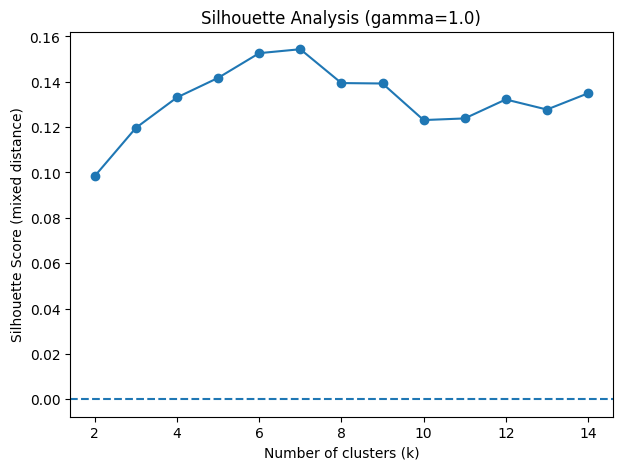

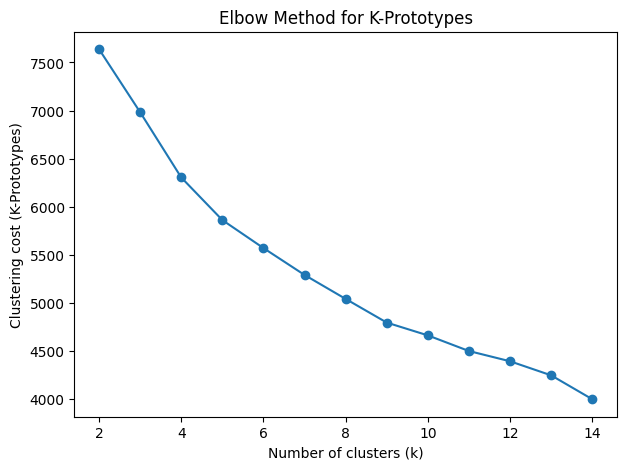

In [91]:
import matplotlib.pyplot as plt
from kmodes.kprototypes import KPrototypes
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import euclidean_distances
import numpy as np

def mixed_distance_matrix(X_num, X_cat, gamma):
    D_num = euclidean_distances(X_num)
    n = X_cat.shape[0]
    D_cat = np.zeros((n, n), dtype=float)
    for i in range(X_cat.shape[1]):
        D_cat += (X_cat[:, i][:, None] != X_cat[:, i]).astype(float)
    return D_num + gamma * D_cat

sil_scores = []
costs = []

K = range(2, 15)

# choose gamma explicitly (good default when numeric block is scaled / PCA’d)
gamma = 1.0

for k in K:
    kp = KPrototypes(n_clusters=k, init="Cao", n_init=10, random_state=0, verbose=0)
    labels = kp.fit_predict(X_kp, categorical=cat_idx)

    D = mixed_distance_matrix(X_num_pca, X_cat, gamma=gamma)
    sil_scores.append(silhouette_score(D, labels, metric="precomputed"))
    costs.append(kp.cost_)

plt.figure(figsize=(7,5))
plt.plot(list(K), sil_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score (mixed distance)")
plt.title(f"Silhouette Analysis (gamma={gamma})")
plt.axhline(0, linestyle="--")
plt.show()

plt.figure(figsize=(7,5))
plt.plot(list(K), costs, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Clustering cost (K-Prototypes)")
plt.title("Elbow Method for K-Prototypes")
plt.show()

# k = 7

Chosen k: 7
kproto_cluster
2    80
5    71
1    70
0    38
4     7
3     7
6     4
Name: count, dtype: int64


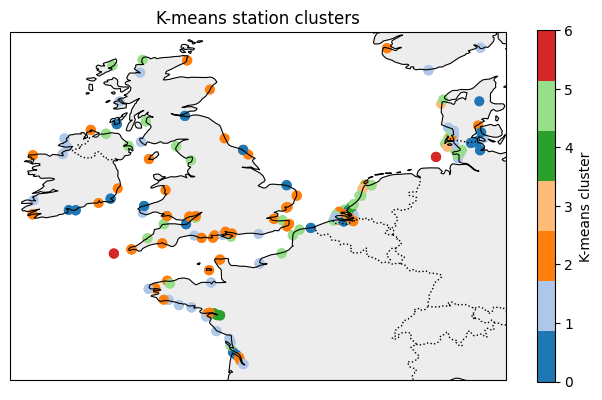

In [94]:
import seaborn as sns
best_k = 7
kp_final = KPrototypes(n_clusters=best_k, init="Huang", n_init=20, random_state=0, verbose=0)
model_df["kproto_cluster"] = kp_final.fit_predict(X_kp, categorical=cat_idx)

print("Chosen k:", best_k)
print(model_df["kproto_cluster"].value_counts())

import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.4)
ax.add_feature(cfeature.OCEAN, facecolor="white")

clusters = sorted(model_df["kproto_cluster"].unique())
n = len(clusters)

colors = sns.color_palette("tab20", n)
cmap = mcolors.ListedColormap(colors)

sc = ax.scatter(
    model_df["lon"],
    model_df["lat"],
    c=model_df["kproto_cluster"],
    cmap=cmap,
    s=40,
    transform=ccrs.PlateCarree()
)

plt.colorbar(sc, ax=ax, label="K-means cluster", shrink=0.57)
ax.set_title("K-means station clusters")
plt.show()

In [96]:
import pandas as pd

ct = pd.crosstab(model_df["kproto_cluster"], model_df["cluster_id"])

# For each proto cluster → take best matching reference cluster
best_matches = ct.max(axis=1)

agreement_pct = best_matches.sum() / len(model_df) * 100

print(f"Robust agreement (many→one mapping): {agreement_pct:.1f}%")


Robust agreement (many→one mapping): 45.5%


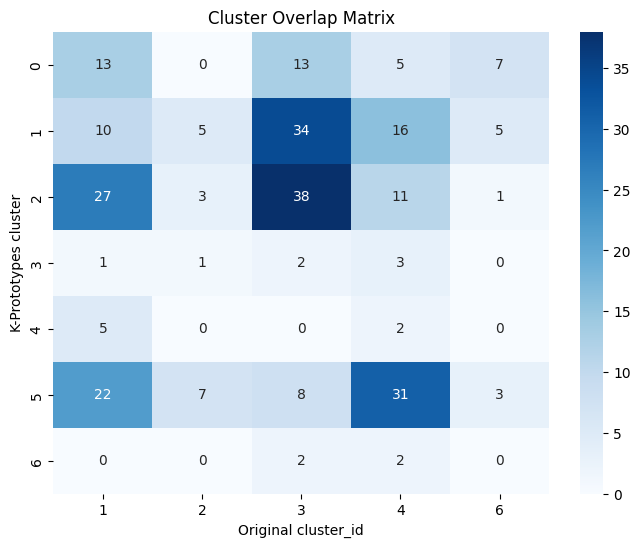

In [97]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues")
plt.title("Cluster Overlap Matrix")
plt.xlabel("Original cluster_id")
plt.ylabel("K-Prototypes cluster")
plt.show()


In [98]:
# Keep only necessary columns
cluster_labels = model_df[["kproto_cluster"]].copy()

# Ensure same index key (usually station)
weather_df = weathercluster_df.copy()

# If both are indexed by station:
merged = weather_df.join(cluster_labels, how="outer")

print("Merged shape:", merged.shape)


Merged shape: (51012, 20)


In [99]:
num_features = merged.select_dtypes(include="number").columns.tolist()
num_features.remove("kproto_cluster")
num_features.remove("cluster")
num_features.remove("lat")
num_features.remove("lon")
num_features.remove("station")
num_features.remove("Unnamed: 0.1")
num_features.remove("Unnamed: 0")

In [100]:
from scipy.stats import gaussian_kde
from scipy.spatial.distance import jensenshannon
import numpy as np

def kde_js_similarity(x, y):
    """Return similarity between two distributions using KDE."""
    xmin = min(x.min(), y.min())
    xmax = max(x.max(), y.max())

    grid = np.linspace(xmin, xmax, 200)

    kde_x = gaussian_kde(x)(grid)
    kde_y = gaussian_kde(y)(grid)

    # Normalize densities
    kde_x /= kde_x.sum()
    kde_y /= kde_y.sum()

    js_dist = jensenshannon(kde_x, kde_y)
    return 1 - js_dist


In [101]:
from numpy.linalg import LinAlgError

results = []

for var in num_features:
    for cid in merged["cluster"].unique():
        if cid in [0, 5]:
            continue
        else:

            for pid in merged["kproto_cluster"].unique():

                x = merged.loc[merged["cluster"] == cid, var].dropna()
                y = merged.loc[merged["kproto_cluster"] == pid, var].dropna()

                # Skip if insufficient data
                if len(x) < 10 or len(y) < 10:
                    continue

                # Skip degenerate distributions
                if x.nunique() < 2 or y.nunique() < 2:
                    continue

                try:
                    sim = kde_js_similarity(x, y)

                    results.append({
                        "variable": var,
                        "cluster": cid,
                        "kproto_cluster": pid,
                        "similarity": sim
                    })

                except LinAlgError:
                # KDE covariance singular → skip safely
                    continue
                except Exception:
                # Catch any other numerical issues
                    continue

overlap_df = pd.DataFrame(results)


In [102]:
merged.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'wind_wave_alignment', 'lat', 'tp', 'lon',
       'mwd', 'mwp', 'wind_dir', 'v10_abs', 'tau_v', 'msl', 'sp', 'v10',
       'u10_abs', 'swh', 'station', 'extract_time', 'cluster',
       'kproto_cluster'],
      dtype='object')

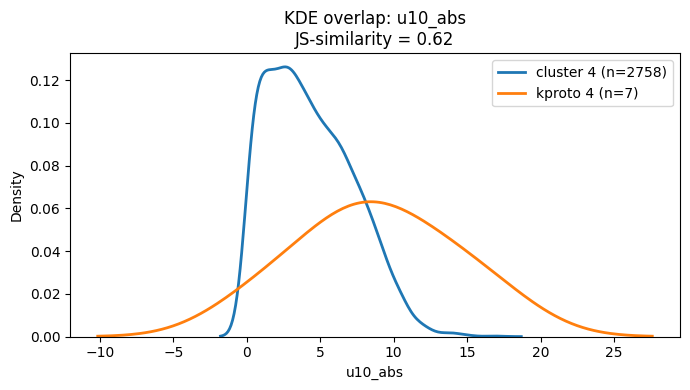

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt
from numpy.linalg import LinAlgError
pid=4
var = "u10_abs"#"sp"# "wind_wave_alignment"
x = merged.loc[merged["cluster"] == cid, var].dropna()
y = merged.loc[merged["kproto_cluster"] == pid, var].dropna()
sim = kde_js_similarity(x, y)
plt.figure(figsize=(7,4))

try:
    sns.kdeplot(x, label=f"cluster {cid} (n={len(x)})", linewidth=2)
    sns.kdeplot(y, label=f"kproto {pid} (n={len(y)})", linewidth=2)

    plt.title(f"KDE overlap: {var}\nJS-similarity = {sim:.2f}")
    plt.xlabel(var)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

except LinAlgError:
    plt.close()
    print("KDE failed due to singular covariance for this example — pick another row.")


In [104]:
# Sort so highest similarities come first
df_sorted = overlap_df.sort_values("similarity", ascending=False)

# Take top 3 variables per cluster pair
top3_per_pair = (
    df_sorted
    .groupby(["cluster", "kproto_cluster"])
    .head(3)
)

cluster_similarity_top3 = (
    top3_per_pair
    .groupby(["cluster", "kproto_cluster"])["similarity"]
    .mean()
    .unstack()
)

top_matches = cluster_similarity_top3.apply(
    lambda row: row.nlargest(3).index.tolist(),
    axis=1
)

rows = []

for cid, proto_list in top_matches.items():
    for pid in proto_list:

        subset = top3_per_pair[
            (top3_per_pair["cluster"] == cid) &
            (top3_per_pair["kproto_cluster"] == pid)
        ].sort_values("similarity", ascending=False)

        for _, r in subset.iterrows():
            rows.append({
                "cluster": cid,
                "kproto_cluster": pid,
                "variable": r["variable"],
                "similarity": r["similarity"]
            })

overlap_explanation = pd.DataFrame(rows)
for cid in overlap_explanation["cluster"].unique():

    print(f"\n===== Original Cluster {cid} =====")

    dfc = overlap_explanation[overlap_explanation["cluster"] == cid]

    for pid in dfc["kproto_cluster"].unique():

        print(f"\n  ↳ Best Proto Cluster {pid}")

        sub = dfc[dfc["kproto_cluster"] == pid]

        for _, r in sub.iterrows():
            print(f"     {r['variable']}  → similarity {r['similarity']:.2f}")



===== Original Cluster 1 =====

  ↳ Best Proto Cluster 0.0
     sp  → similarity 0.94
     msl  → similarity 0.92
     wind_wave_alignment  → similarity 0.89

  ↳ Best Proto Cluster 1.0
     sp  → similarity 0.90
     msl  → similarity 0.90
     wind_wave_alignment  → similarity 0.87

  ↳ Best Proto Cluster 2.0
     wind_wave_alignment  → similarity 0.90
     sp  → similarity 0.85
     tp  → similarity 0.85

===== Original Cluster 2 =====

  ↳ Best Proto Cluster 2.0
     wind_wave_alignment  → similarity 0.91
     u10_abs  → similarity 0.83
     msl  → similarity 0.70

  ↳ Best Proto Cluster 1.0
     wind_wave_alignment  → similarity 0.89
     u10_abs  → similarity 0.79
     v10_abs  → similarity 0.73

  ↳ Best Proto Cluster 0.0
     wind_wave_alignment  → similarity 0.90
     u10_abs  → similarity 0.83
     msl  → similarity 0.64

===== Original Cluster 3 =====

  ↳ Best Proto Cluster 0.0
     sp  → similarity 0.89
     wind_wave_alignment  → similarity 0.89
     msl  → similarity 0.

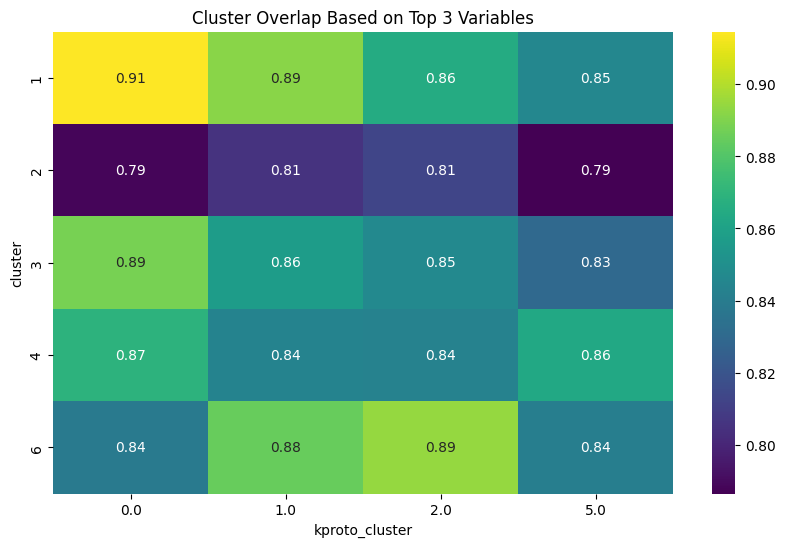

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(cluster_similarity_top3, annot=True, cmap="viridis")
plt.title("Cluster Overlap Based on Top 3 Variables")
plt.show()


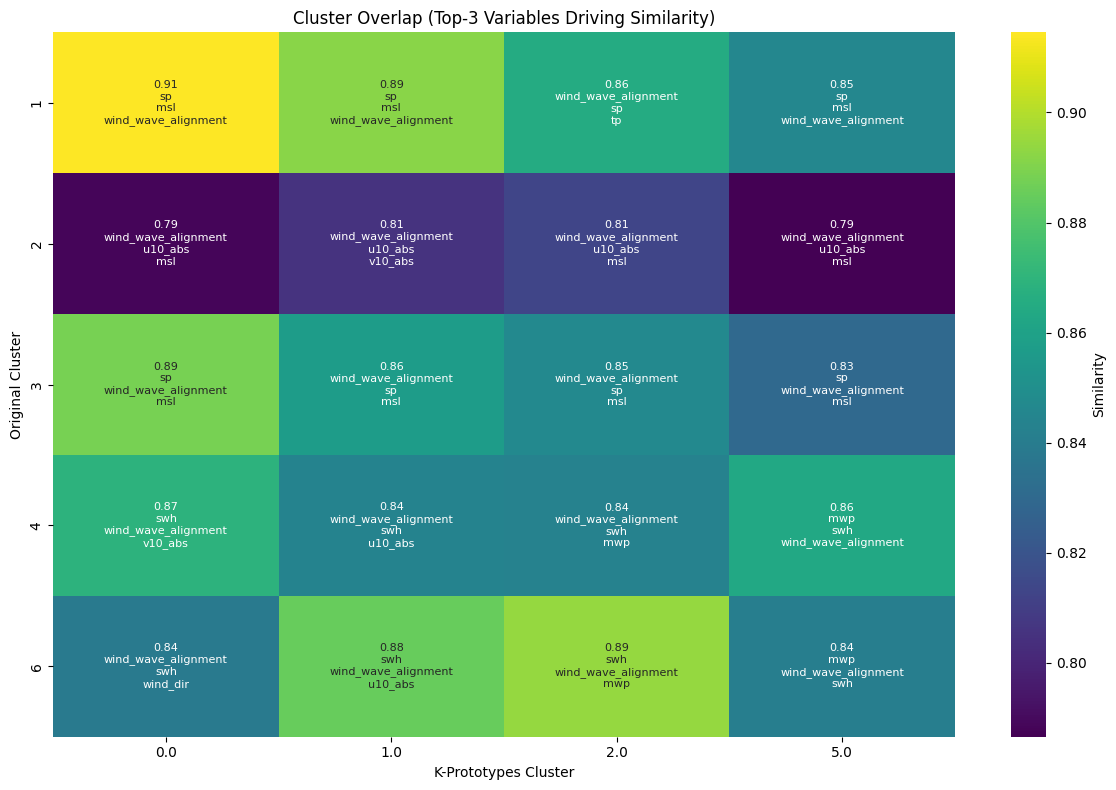

In [106]:
# Create annotation text matrix
annot_matrix = cluster_similarity_top3.copy().astype(str)

for cid in cluster_similarity_top3.index:
    for pid in cluster_similarity_top3.columns:

        subset = top3_per_pair[
            (top3_per_pair["cluster"] == cid) &
            (top3_per_pair["kproto_cluster"] == pid)
        ]

        if subset.empty:
            annot_matrix.loc[cid, pid] = ""
            continue

        vars_list = subset["variable"].tolist()
        score = cluster_similarity_top3.loc[cid, pid]

        annot_matrix.loc[cid, pid] = (
            f"{score:.2f}\n" +
            "\n".join(vars_list)
        )
        
plt.figure(figsize=(12,8))

sns.heatmap(
    cluster_similarity_top3,
    annot=annot_matrix,
    fmt="",
    cmap="viridis",
    cbar_kws={"label": "Similarity"},
    annot_kws={"size": 8}
)

plt.title("Cluster Overlap (Top-3 Variables Driving Similarity)")
plt.xlabel("K-Prototypes Cluster")
plt.ylabel("Original Cluster")
plt.tight_layout()
plt.show()



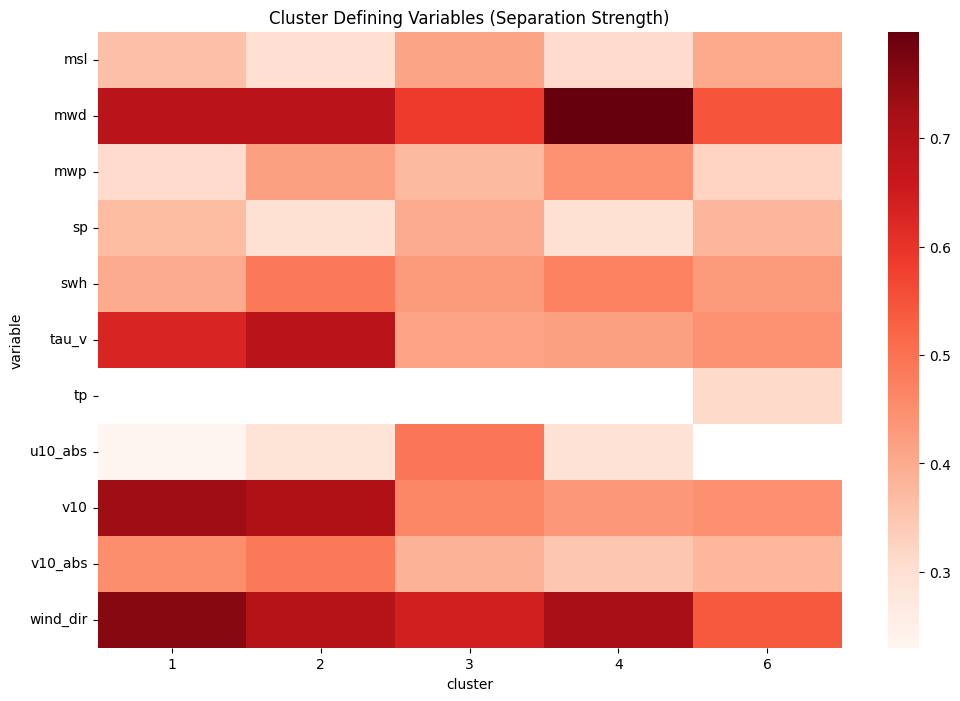

In [107]:
signature_rows = []

clusters = merged["cluster"].unique()

for var in num_features:

    for cid in clusters:

        if cid in [0, 5]:   # keep your exclusion
            continue

        x = merged.loc[merged["cluster"] == cid, var].dropna()

        if len(x) < 15 or x.nunique() < 2:
            continue

        similarities = []

        for other in clusters:
            if other == cid or other in [0, 5]:
                continue

            y = merged.loc[merged["cluster"] == other, var].dropna()

            if len(y) < 15 or y.nunique() < 2:
                continue

            try:
                sim = kde_js_similarity(x, y)
                similarities.append(sim)

            except:
                continue

        if len(similarities) == 0:
            continue

        # Separation = how different from others
        separation = 1 - np.mean(similarities)

        signature_rows.append({
            "cluster": cid,
            "variable": var,
            "separation_score": separation,
            "avg_similarity_to_others": np.mean(similarities)
        })

signature_df = pd.DataFrame(signature_rows)
top_signatures = (
    signature_df
    .sort_values(["cluster", "separation_score"], ascending=[True, False])
    .groupby("cluster")
    .head(10)
)

top_signatures.head(20)

pivot_sig = top_signatures.pivot_table(
    index="variable",
    columns="cluster",
    values="separation_score"
)

plt.figure(figsize=(12,8))
sns.heatmap(pivot_sig, cmap="Reds")
plt.title("Cluster Defining Variables (Separation Strength)")
plt.show()


In [109]:
cluster_similarity = (
    overlap_df
    .groupby(["cluster", "kproto_cluster"])["similarity"]
    .mean()
    .unstack()
)

print(cluster_similarity)


kproto_cluster       0.0       1.0       2.0       5.0
cluster                                               
1               0.694757  0.744892  0.731754  0.683375
2               0.555518  0.555975  0.558788  0.545062
3               0.671812  0.644191  0.654978  0.642230
4               0.675127  0.665419  0.662455  0.698171
6               0.644445  0.655197  0.665710  0.663271


In [110]:
top2_matches = cluster_similarity.apply(
    lambda row: row.nlargest(3).index.tolist(),
    axis=1
)
top2_matches

cluster
1    [1.0, 2.0, 0.0]
2    [2.0, 1.0, 0.0]
3    [0.0, 2.0, 1.0]
4    [5.0, 0.0, 1.0]
6    [2.0, 5.0, 1.0]
dtype: object

In [111]:
var_sep = overlap_df.groupby("variable")["similarity"].mean().sort_values()
print(var_sep.head(15))


variable
mwd                    0.507106
wind_dir               0.510395
v10                    0.536145
tau_v                  0.541281
swh                    0.611631
v10_abs                0.667238
tp                     0.676919
mwp                    0.696699
msl                    0.710593
sp                     0.712209
u10_abs                0.760414
wind_wave_alignment    0.877247
Name: similarity, dtype: float64


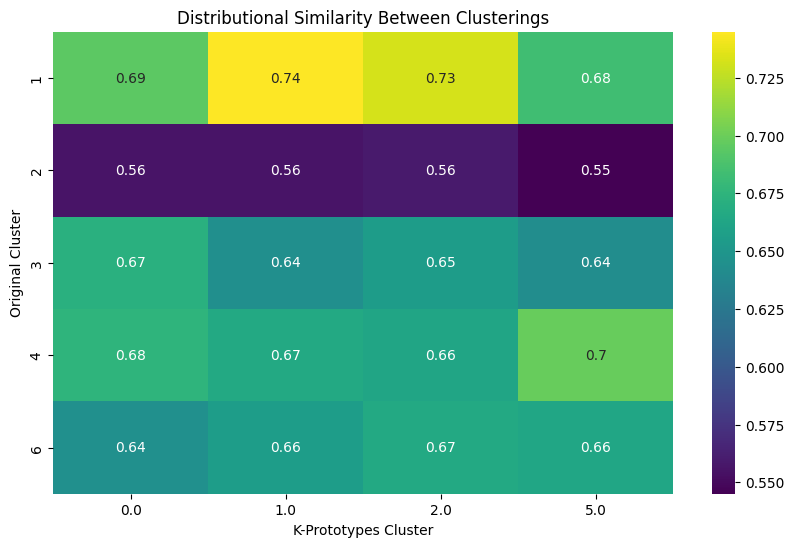

In [112]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(cluster_similarity, annot=True, cmap="viridis")
plt.title("Distributional Similarity Between Clusterings")
plt.xlabel("K-Prototypes Cluster")
plt.ylabel("Original Cluster")
plt.show()


In [113]:
cluster_means = merged.groupby("kproto_cluster")[num_features].mean()

importance = cluster_means.var().sort_values(ascending=False)

top_vars = importance.head(12).index.tolist()

print("Most separating weather features:")
print(top_vars)


Most separating weather features:
['sp', 'msl', 'wind_dir', 'mwd', 'u10_abs', 'v10', 'v10_abs', 'mwp', 'wind_wave_alignment', 'tau_v', 'swh', 'tp']


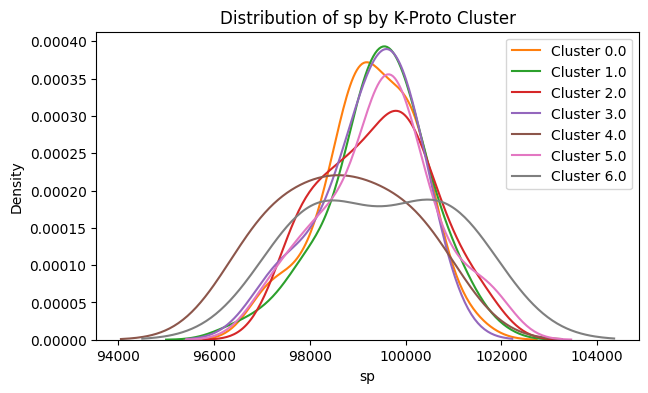

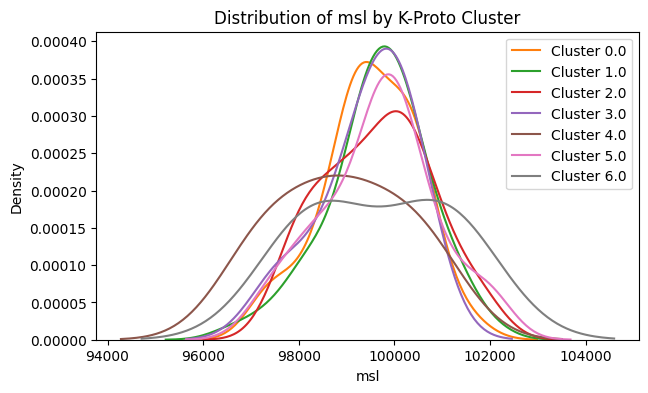

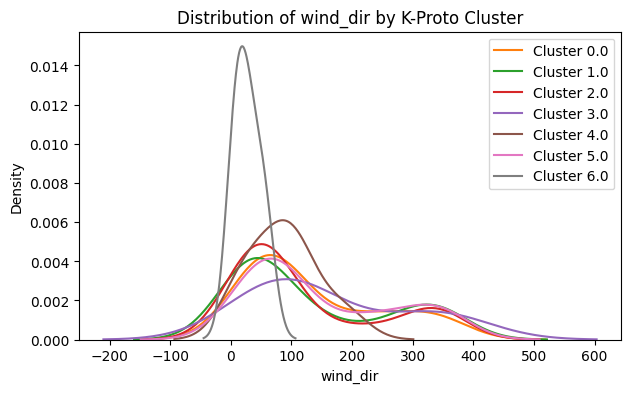

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_34992/2711871249.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(subset, label=f"Cluster {c}", fill=False)


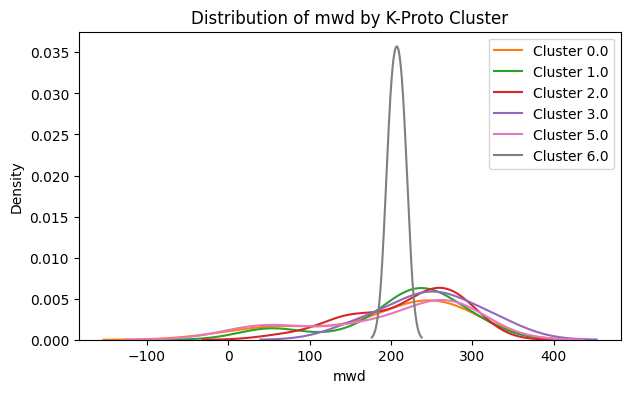

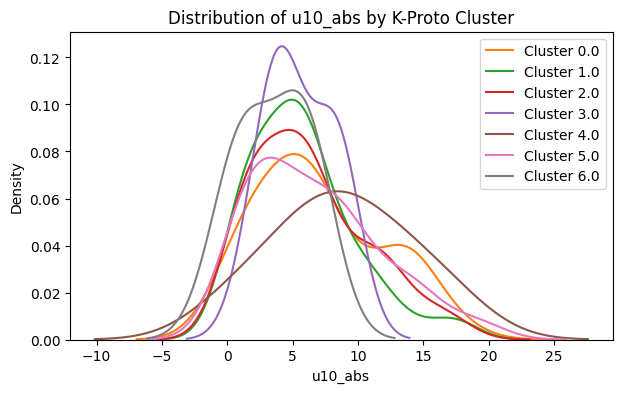

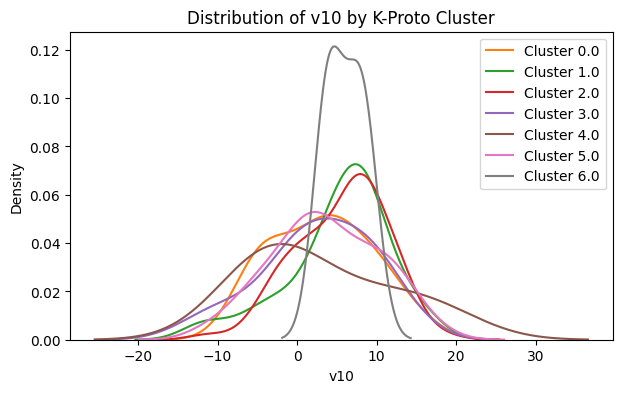

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt

for var in top_vars[:6]:  # plot top 6 first
    plt.figure(figsize=(7,4))

    for c in sorted(merged["kproto_cluster"].unique()):
        subset = merged[merged["kproto_cluster"] == c][var]
        sns.kdeplot(subset, label=f"Cluster {c}", fill=False)

    plt.title(f"Distribution of {var} by K-Proto Cluster")
    plt.xlabel(var)
    plt.ylabel("Density")
    plt.legend()
    plt.show()


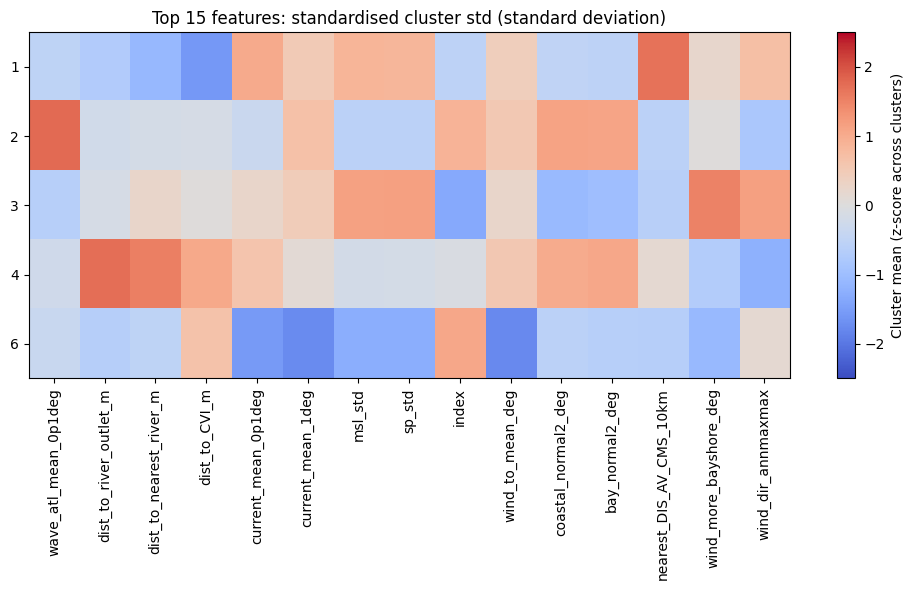

In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cluster = model_df["cluster_id"]
df = X.copy()
df["kmodes_cluster"] = cluster.values
df = df.loc[:, ~df.columns.str.contains("Unnamed", case=False)]
df = df.loc[:, ~df.columns.str.contains("station", case=False)]
df = df.loc[:, ~df.columns.str.contains("lat", case=False)]
df = df.loc[:, ~df.columns.str.contains("lon", case=False)]
# Per-cluster summary
means = df.groupby("kmodes_cluster").mean(numeric_only=True)
stds  = df.groupby("kmodes_cluster").std(numeric_only=True)
counts = df.groupby("kmodes_cluster").size()
var_score = means.std(axis=0)

top_n = 15
top_features = var_score.sort_values(ascending=False).head(top_n).index

means_top = means[top_features]
stds_top  = stds[top_features]

# Z-score across clusters (per feature)
Z = (means_top - means_top.mean(axis=0)) / (means_top.std(axis=0) + 1e-12)

plt.figure(figsize=(10, 6))
plt.imshow(Z, aspect="auto", cmap="coolwarm", vmin=-2.5, vmax=2.5)
plt.colorbar(label="Cluster mean (z-score across clusters)")

plt.yticks(range(len(Z.index)), Z.index)
plt.xticks(range(len(Z.columns)), Z.columns, rotation=90)
plt.title(f"Top {top_n} features: standardised cluster std (standard deviation)")
plt.tight_layout()
plt.show()